<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Natural Language Processing  - Neural Network - Sentiment Analysis Amazon, Yelp
</b></font> </br></p>

---

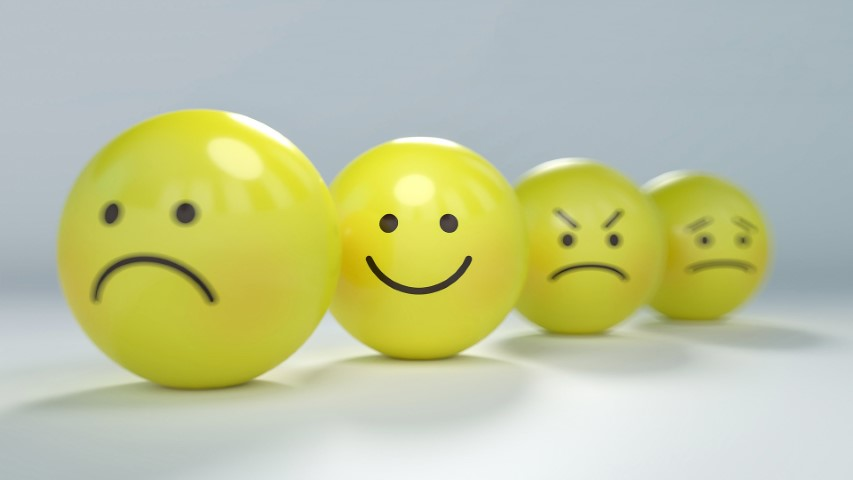

Bild von <a href="https://pixabay.com/de/users/absolutvision-6158753/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=2979107">Gino Crescoli</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=2979107">Pixabay</a>

# **0 | Install & Import**
---

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame, concat
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras import Sequential
from keras.layers import Embedding, Flatten, Dense, Dropout, ActivityRegularization
from keras import regularizers
from keras.utils import set_random_seed, plot_model

from tensorflow import keras
from tensorflow.config.experimental import enable_op_determinism
import tensorflow as tf

import plotly.express as px

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
---

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---   


„The Social Dilemma“, ein Dokumentarfilm-Drama-Hybrid, untersucht die gefährlichen menschlichen Auswirkungen sozialer Netzwerke. Erstveröffentlichung: Januar 2020 Regie: Jeff Orlowski Produzentin: Larissa Rhodes Musikalische Leitung: Mark A. Crawford Drehbuch: Jeff Orlowski, Vickie Curtis, Davis Coombe.

Dieser Datensatz zeigt Ihnen die Twitter-Antworten mit dem Hashtag TheSocialDilemma, nachdem Sie sich die aufschlussreiche Dokumentation angesehen haben „The Social Dilemma“ wurde am 9. September 2020 auf einer OTT-Plattform (Netflix) veröffentlicht. Der Datensatz wurde mit TwitterAPI extrahiert und besteht aus fast 10.526 Tweets von Twitter-Nutzern auf der ganzen Welt!



[Info](https://www.openml.org/search?type=data&status=active&id=43532)

[DataSet](https://www.openml.org/search?type=data&status=active&id=43532)






Foto von <a href="https://unsplash.com/@nhillier?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Nick Hillier</a> auf <a href="https://unsplash.com/de/fotos/yD5rv8_WzxA?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
  

In [ ]:
df = read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/sentiment.csv')

In [ ]:
data = df.copy()
target = data.pop("Sentiment")

# **2 | Prepare**
---


<p><font color='black' size="5">
Tokenizer
</font></p>

Der Datensatz wird tokenisiert (`Tokenizer`). Jedem Wort wird eine eindeutige Nummer zugewiesen – die für das neuronale Netzwerk erforderlich ist, um die Eingabe zu interpretieren.
   
[Tokenizer](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer)

In [ ]:
num_words_ = 10000  # die maximale Anzahl der zu behaltenden Wörter, basierend auf der Worthäufigkeit
oov_tok_ = "<OOV>"  # wird zu word_index hinzugefügt & und bei fehlenden Wörte bei text_to_sequence-Aufrufen verwendet

In [ ]:
tokenizer = Tokenizer(num_words=num_words_, oov_token=oov_tok_)
tokenizer.fit_on_texts(data.text)
word_index = tokenizer.word_index

In [ ]:
type(word_index), len(word_index)

(dict, 31610)

In [ ]:
word_index

{'<OOV>': 1,
 'thesocialdilemma': 2,
 't': 3,
 'co': 4,
 'https': 5,
 'the': 6,
 'to': 7,
 'on': 8,
 'and': 9,
 'a': 10,
 'is': 11,
 'i': 12,
 'social': 13,
 'netflix': 14,
 'you': 15,
 'watch': 16,
 'of': 17,
 'it': 18,
 'this': 19,
 'media': 20,
 'in': 21,
 'are': 22,
 'for': 23,
 'that': 24,
 'watching': 25,
 'watched': 26,
 'if': 27,
 'we': 28,
 'about': 29,
 'my': 30,
 'just': 31,
 'documentary': 32,
 'not': 33,
 'how': 34,
 'dilemma': 35,
 'have': 36,
 'but': 37,
 'me': 38,
 'all': 39,
 'product': 40,
 'with': 41,
 'be': 42,
 'must': 43,
 'what': 44,
 'your': 45,
 'so': 46,
 'its': 47,
 'everyone': 48,
 'do': 49,
 'now': 50,
 'from': 51,
 'an': 52,
 'as': 53,
 'has': 54,
 'twitter': 55,
 'was': 56,
 'after': 57,
 'our': 58,
 'people': 59,
 'know': 60,
 'like': 61,
 'should': 62,
 "it's": 63,
 'out': 64,
 'amp': 65,
 'time': 66,
 'by': 67,
 'then': 68,
 'up': 69,
 'one': 70,
 'at': 71,
 'us': 72,
 'more': 73,
 'they': 74,
 'who': 75,
 'im': 76,
 'or': 77,
 'facebook': 78,
 'really

<p><font color='black' size="5">
Text 2 Sequenz
</font></p>

Diese Tokens (Wörter) werden dann in Sequenzen sortiert, um sicherzustellen, dass die Tokens für jedes Wort der richtigen Reihenfolge folgen, wie sie von jedem Satz vorgegeben wird.


[text_to_word_sequence](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/text_to_word_sequence)

In [ ]:
sequences = tokenizer.texts_to_sequences(data.text)

<p><font color='black' size="5">
Padding
</font></p>

Damit jeder Satz gleich lang ist, werden am Ende eines Satzes Nullen einfügt. Dies ist erforderlich, wenn ein Satz länger als ein anderer ist, da jeder Satz zum Zweck der Analyse durch das RNN gleich lang sein muss.

[pad_sequence](https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences)

In [ ]:
max_length = 100  # optional, maximale Länge der Sequenzen
trunc_type = "post"  # Entfernt Worte aus Sequenzen, die größer als maxlen sind, entweder am Anfang oder am Ende der Sequenzen
padding_type = "post"  # Auffüllen entweder vor oder nach jeder Sequenz

data_padded = pad_sequences(
    sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type
)

<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data_padded, target, test_size=0.3, random_state=42, stratify=target
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

((14047, 100), (6021, 100), (14047,), (6021,))

<p><font color='black' size="5">
Konvertierung einer Klassen (Ganzzahlen) in einen Klassenvektor (Output)
</font></p>

In [ ]:
num_classes = 3
target_train.replace(["Negative", "Neutral", "Positive"], [0, 1, 2], inplace=True)
target_train = to_categorical(target_train, num_classes)
target_test.replace(["Negative", "Neutral", "Positive"], [0, 1, 2], inplace=True)
target_test = to_categorical(target_test, num_classes)

# **3 | Modeling**
---

<p><font color='black' size="5">
Schrittweise Modellierung eines Neuronalen Netzes
</font></p>

[Core layers](https://keras.io/api/layers/core_layers/)    
[Reshaping layers](https://keras.io/api/layers/reshaping_layers/)   
[Layer activation functions](https://keras.io/api/layers/activations/)   


<p><font color='black' size="5">
Zufallszahl initialisieren
</font></p>

In [ ]:
set_random_seed(42)
enable_op_determinism()

<p><font color='black' size="5">
Modellaufbau
</font></p>

In [ ]:
input_dim_ = num_words_
emb_dim_ = 512
model = Sequential()
model.add(keras.Input(shape=(max_length,)))
model.add(Embedding(input_dim_, emb_dim_, input_length=max_length))
model.add(Flatten())
model.add(Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.15)))
model.add(Dropout(0.5))
model.add(Dense(3, activation="softmax"))

<p><font color='black' size="5">
Compile
</font></p>

In [ ]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

<p><font color='black' size="5">
Einfaches Layer-Diagramm
</font></p>

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 512)       │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       819,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,939,267 (22.66 MB)

 Trainable params: 5,939,267 (22.66 MB)

 Non-trainable params: 0 (0.00 B)

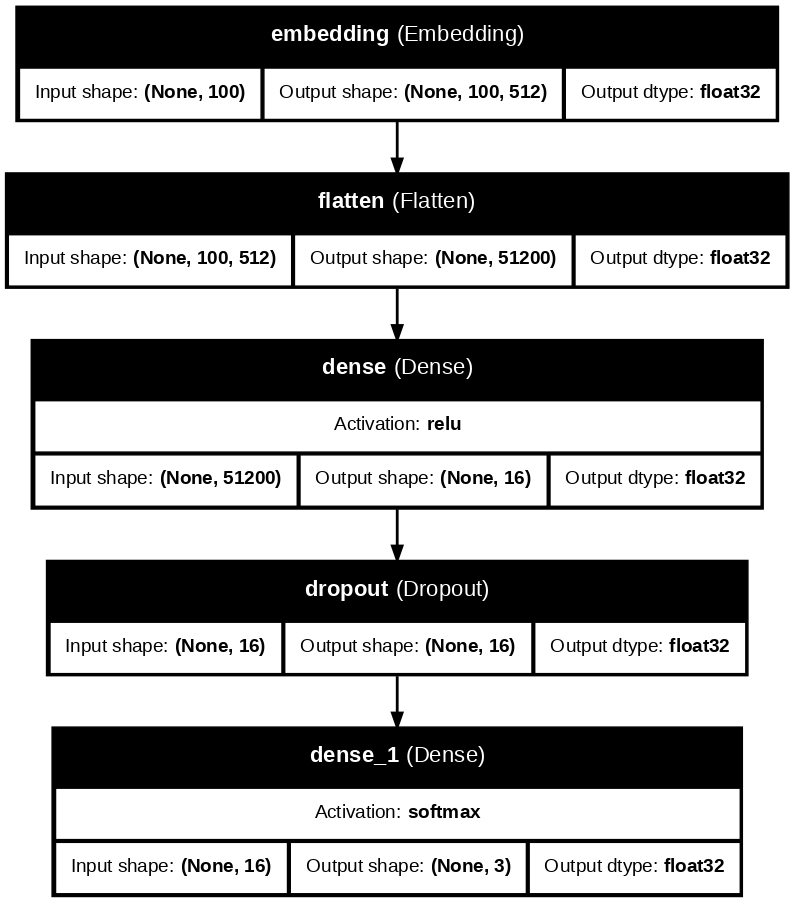

In [ ]:
# Visualisierung neuronales Netz
plot_model(
    model,
    to_file="nn_structure.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    dpi=100,
    expand_nested=True,
    show_layer_activations=True
)

In [ ]:
# Anzahl Parameter je Layer
for layer in model.layers:
    print(f"{layer.name}: {layer.count_params()} Parameter")

embedding: 5120000 Parameter
flatten: 0 Parameter
dense: 819216 Parameter
dropout: 0 Parameter
dense_1: 51 Parameter


<p><font color='black' size="5">
Training
</font></p>


In [ ]:
epochs_ = 25
batch_size_ = 126

In [ ]:
model.fit(
    data_train,
    target_train,
    batch_size=batch_size_,
    validation_split=0.3,
    epochs=epochs_,
)

Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4621 - loss: 1.9968 - val_accuracy: 0.6002 - val_loss: 1.0353
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5587 - loss: 1.0394 - val_accuracy: 0.6631 - val_loss: 0.9569
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6413 - loss: 0.9752 - val_accuracy: 0.7030 - val_loss: 0.8801
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7009 - loss: 0.8883 - val_accuracy: 0.7265 - val_loss: 0.8330
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7501 - loss: 0.8194 - val_accuracy: 0.7696 - val_loss: 0.7890
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7831 - loss: 0.7583 - val_accuracy: 0.7552 - val_loss: 0.7825
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8049 - loss: 0.7173 - val_accuracy: 0.7794 - val_loss: 0.7466
Epoch 8/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8134 - loss: 0.6985 - val_accuracy: 0.7986 - v

In [ ]:
print(model.history.params)
print(model.history.history.keys())

{'verbose': 'auto', 'epochs': 25, 'steps': 79}
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


<p><font color='black' size="5">
Loss-Entwicklung
</font></p>

In [ ]:
title_ = "Loss-Entwicklung"
px.line(
    y=model.history.history["loss"],
    title=title_,
    labels={"x": "Epochen", "y": "Loss-Wert"},
    width=800,
    height=400,
)

# 4 | Evaluate
---

<p><font color='black' size="5">
Prognose
</font></p>

In [35]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

array([[0.024346  , 0.895228  , 0.08042593],
       [0.87967396, 0.06882822, 0.05149775],
       [0.07718989, 0.8864101 , 0.03639994],
       ...,
       [0.03539833, 0.11053227, 0.8540694 ],
       [0.06468081, 0.765205  , 0.17011425],
       [0.02354287, 0.03634862, 0.94010854]], dtype=float32)

In [42]:
tf.argmax(target_train_pred, axis=1).numpy()

array([1, 1, 2, ..., 0, 1, 2])

In [41]:
# --- Vorverarbeitung: Umwandlung Array mit Wahrscheinlichkeiten in Array mit 0/1
def probabilities_to_binary(matrix):
    max_indices = tf.keras.backend.argmax(matrix, axis=1)
    binary_matrix = tf.keras.backend.one_hot(max_indices, matrix.shape[1])
    return binary_matrix

In [ ]:
target_train_pred_ = probabilities_to_binary(target_train_pred)
target_test_pred_ = probabilities_to_binary(target_test_pred)

<p><font color='black' size="5">
Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred_) * 100
print(f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

Modell: <Sequential name=sequential, built=True> -- Train -- Accuracy: 91.12


In [ ]:
target_test_pred_ = target_test_pred.round(decimals=0)
acc_test = accuracy_score(target_test, target_test_pred_) * 100
print(f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}")

Modell: <Sequential name=sequential, built=True> -- Test -- Accuracy: 77.86


<p><font color='black' size="5">
Confusion Matrix
</font></p>

In [ ]:
max_cols_test_pred = DataFrame(target_test_pred_).idxmax(axis=1)
max_cols_test = DataFrame(target_test).idxmax(axis=1)

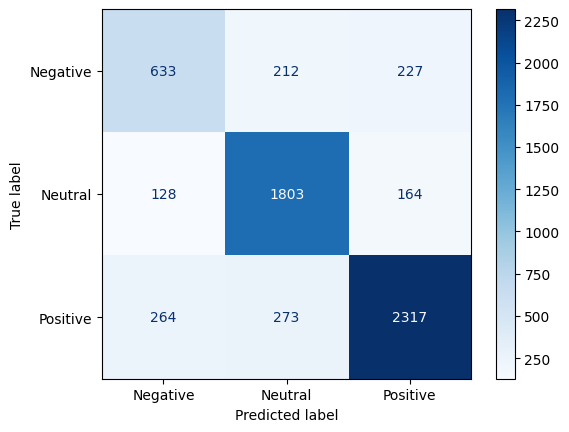

In [ ]:
conf_matrix = confusion_matrix(max_cols_test, max_cols_test_pred)
display_labels_ = ["Negative", "Neutral", "Positive"]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
disp.plot(cmap="Blues")

In [ ]:
print(
    classification_report(
        max_cols_test, max_cols_test_pred, target_names=display_labels_
    )
)

              precision    recall  f1-score   support

    Negative       0.62      0.59      0.60      1072
     Neutral       0.79      0.86      0.82      2095
    Positive       0.86      0.81      0.83      2854

    accuracy                           0.79      6021
   macro avg       0.75      0.75      0.75      6021
weighted avg       0.79      0.79      0.79      6021



<p><font color='black' size="5">
Einzelne Aussagen - Real vs Predict
</font></p>

In [ ]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])


def decode_review(text):
    return " ".join([reverse_word_index.get(i, "") for i in text])

In [ ]:
for example in range(0, 10):
    print(
        "real: ",
        max_cols_test[example],
        "predict: ",
        int(np.around(float(max_cols_test_pred[example]), 0)),
        " -- ",
        decode_review(data_test[example]),
        sep=" ",
    )

real:  1 predict:  1  --  saturday morning cartoons were 30 minute commercials tristaaaaaaan thesocialdilemma https t co oih3m4ivu1                                                                                       
real:  0 predict:  0  --  yup especially after watching thesocialdilemma it's scary how easy it is to manipulate elections https t co <OOV>                                                                                  
real:  1 predict:  1  --  thesocialdilemma netflix watch it and think                                                                                              
real:  1 predict:  1  --  i watched thesocialdilemma tonight on netflix and i'm not kidding when i say it should be required viewing not https t co <OOV>                                                                             
real:  2 predict:  2  --  if you know whats good for you and your place in this world pls dear god go watch thesocialdilemma on netflix                             

# 5 | Deploy
---